# MLP with Dimensionless Parameters — Case 1
Rectangular plate → differential area element  
Features: h/d, k/d, L/d, P/d, R/d

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import time

size_text = 24
plt.rcParams.update({
    'font.family': 'serif',
    'text.usetex': False,
    'axes.titlesize': size_text,
    'axes.labelsize': size_text,
    'xtick.labelsize': size_text,
    'ytick.labelsize': size_text,
    'legend.fontsize': size_text,
})
w, h_fig = 10, 6


## Dataset and dimensionless features

In [18]:
# Physical constants (fixed for this dataset)
L = 100.0   # plate length  (mm)
P =  80.0   # plate width   (mm)
R =   1e-1  # disk radius   (mm)

df = pd.read_csv("../data/Case_1.csv")

# Build dimensionless groups
df['h_d'] = df['h'] / df['d']
df['k_d'] = df['k'] / df['d']
df['L_d'] = L       / df['d']
df['P_d'] = P       / df['d']
df['R_d'] = R       / df['d']

feat_names = ['h_d', 'k_d', 'L_d', 'P_d', 'R_d']
X = df[feat_names].values
y = df['F'].values.reshape(-1, 1)

print(f"Dataset shape: {df.shape}")
print(f"\nDimensionless feature ranges:")
for f in feat_names:
    print(f"  {f:>5s}: [{df[f].min():.4f}, {df[f].max():.4f}]  ({df[f].nunique()} unique values)")

print("\nNote: L/d, P/d and R/d are perfectly collinear in this dataset")
print("(L, P, R are fixed constants — all three equal constant/d).")
print("The formulation remains physically correct and generalises")
print("to datasets where L, P or R are varied.")


Dataset shape: (37500, 9)

Dimensionless feature ranges:
    h_d: [-5.0000, 5.0000]  (711 unique values)
    k_d: [-5.0000, 5.0000]  (711 unique values)
    L_d: [1.2500, 10.0000]  (15 unique values)
    P_d: [1.0000, 8.0000]  (15 unique values)
    R_d: [0.0013, 0.0100]  (15 unique values)

Note: L/d, P/d and R/d are perfectly collinear in this dataset
(L, P, R are fixed constants — all three equal constant/d).
The formulation remains physically correct and generalises
to datasets where L, P or R are varied.


## Train – Test split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")


Train: 30000 samples  |  Test: 7500 samples


## Scaling and tensor conversion

In [20]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_test_scaled  = scaler_y.transform(y_test).ravel()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_scaled.reshape(-1,1), dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test_scaled,  dtype=torch.float32).to(device)
y_test_tensor  = torch.tensor(y_test_scaled.reshape(-1,1),  dtype=torch.float32).to(device)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds  = TensorDataset(X_test_tensor,  y_test_tensor)
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=256, shuffle=False)


Using device: cuda


## MLP architecture  (5 dimensionless inputs)

In [21]:
class MLP(nn.Module):
    def __init__(self, in_dim: int = 5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.GELU(),
            nn.Linear(64, 64),    nn.GELU(),
            nn.Linear(64, 32),    nn.GELU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model = MLP().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"MLP parameters: {n_params:,}  ({n_params*4/1024:.1f} KB)")


MLP parameters: 6,657  (26.0 KB)


## Training

In [22]:
loss_fn   = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def rmse(pred, target):
    return torch.sqrt(nn.functional.mse_loss(pred, target))

EPOCHS = 300
train_rmse_list, test_rmse_list = [], []

t0 = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        rmse_train = rmse(model(X_train_tensor), y_train_tensor).item()
        rmse_test  = rmse(model(X_test_tensor),  y_test_tensor).item()

    train_rmse_list.append(rmse_train)
    test_rmse_list.append(rmse_test)

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | RMSE_train: {rmse_train:.4e} | RMSE_test: {rmse_test:.4e}")

T_train = time.perf_counter() - t0

model.eval()
with torch.no_grad():
    t2 = time.perf_counter()
    _ = model(X_test_tensor)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    T_pred = (time.perf_counter() - t2) / X_test_tensor.shape[0]

print(f"\nTraining time : {T_train:.2f} s")
print(f"Inference time: {T_pred*1e6:.4f} µs/sample")


Epoch   1 | RMSE_train: 3.0028e-01 | RMSE_test: 3.0505e-01
Epoch  50 | RMSE_train: 9.0067e-03 | RMSE_test: 9.1157e-03
Epoch 100 | RMSE_train: 5.8123e-03 | RMSE_test: 5.9417e-03
Epoch 150 | RMSE_train: 5.3289e-03 | RMSE_test: 5.5587e-03
Epoch 200 | RMSE_train: 5.3366e-03 | RMSE_test: 5.5159e-03
Epoch 250 | RMSE_train: 3.9189e-03 | RMSE_test: 4.0078e-03
Epoch 300 | RMSE_train: 5.4688e-03 | RMSE_test: 5.6089e-03

Training time : 41.56 s
Inference time: 0.0350 µs/sample


## Learning curves

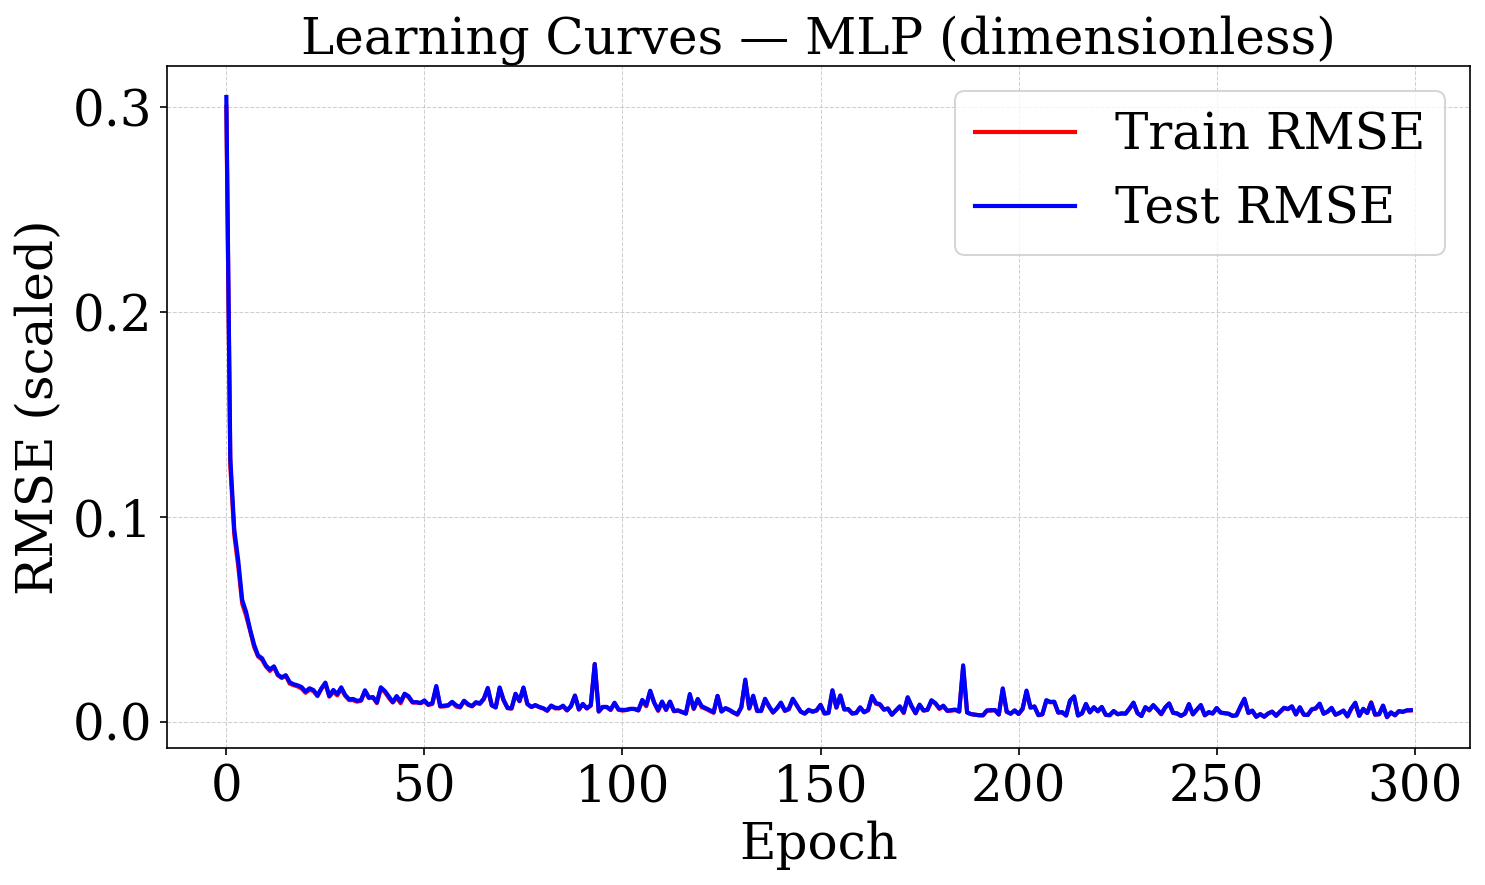

In [23]:
fig, ax = plt.subplots(figsize=(w, h_fig), dpi=150)
ax.plot(train_rmse_list, 'r-', linewidth=2, label='Train RMSE')
ax.plot(test_rmse_list,  'b-', linewidth=2, label='Test RMSE')
ax.set_title("Learning Curves — MLP (dimensionless)")
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE (scaled)")
ax.legend()
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.savefig("learning_curve_mlp_dimless.pdf", dpi=400, bbox_inches='tight')
plt.show()


## Metrics

In [24]:
model.eval()
with torch.no_grad():
    y_train_pred_s = model(X_train_tensor).cpu().numpy()
    y_test_pred_s  = model(X_test_tensor).cpu().numpy()

y_train_pred = scaler_y.inverse_transform(y_train_pred_s)
y_test_pred  = scaler_y.inverse_transform(y_test_pred_s)
y_train_true = scaler_y.inverse_transform(y_train_tensor.cpu().numpy())
y_test_true  = scaler_y.inverse_transform(y_test_tensor.cpu().numpy())

def metrics(yt, yp, label):
    mse  = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(yt, yp)
    r2   = r2_score(yt, yp)
    mape = np.mean(np.abs((yt - yp) / yt)) * 100
    print(f"{label}:")
    print(f"  MSE  = {mse:.4e}  |  RMSE = {rmse:.4e}")
    print(f"  MAE  = {mae:.4e}  |  R²   = {r2:.8f}")
    print(f"  MAPE = {mape:.4f} %")
    return mse, rmse, mae, r2, mape

_, _, _, _, mape_train = metrics(y_train_true, y_train_pred, "Train")
_, _, _, _, mape_test  = metrics(y_test_true,  y_test_pred,  "Test")


Train:
  MSE  = 1.8334e-17  |  RMSE = 4.2819e-09
  MAE  = 2.8742e-09  |  R²   = 0.99997008
  MAPE = 0.1845 %
Test:
  MSE  = 1.9286e-17  |  RMSE = 4.3916e-09
  MAE  = 2.8895e-09  |  R²   = 0.99996817
  MAPE = 0.1861 %


## Prediction error bands (test set)

In [25]:
rel_err = np.abs((y_test_true - y_test_pred) / y_test_true)
print("Percentage of test predictions within tolerance:")
for tol in [0.01, 0.02, 0.05, 0.10]:
    pct = np.mean(rel_err < tol) * 100
    print(f"  < {tol*100:.0f}%  →  {pct:.2f}%")


Percentage of test predictions within tolerance:
  < 1%  →  98.21%
  < 2%  →  99.75%
  < 5%  →  100.00%
  < 10%  →  100.00%


## Comparison: dimensional (h, k, d)  vs  dimensionless (h/d, k/d, L/d, P/d, R/d)

In [26]:
# Original dimensional model results (from Neural_network_case_1.ipynb)
mape_dim  = 0.2105   # % — test MAPE of the dimensional MLP
r2_dim    = 0.999956
rmse_dim  = 5.14e-9

print(f"{'Metric':<20} {'Dimensional':>15} {'Dimensionless':>15}")
print("-" * 52)
print(f"{'MAPE test (%)':<20} {mape_dim:>15.4f} {mape_test:>15.4f}")
print(f"{'R² test':<20} {r2_dim:>15.6f} {r2_score(y_test_true, y_test_pred):>15.6f}")
print(f"{'RMSE test':<20} {rmse_dim:>15.4e} {np.sqrt(mean_squared_error(y_test_true, y_test_pred)):>15.4e}")


Metric                   Dimensional   Dimensionless
----------------------------------------------------
MAPE test (%)                 0.2105          0.1861
R² test                     0.999956        0.999968
RMSE test                 5.1400e-09      4.3916e-09


## Predicted vs actual values (test set)

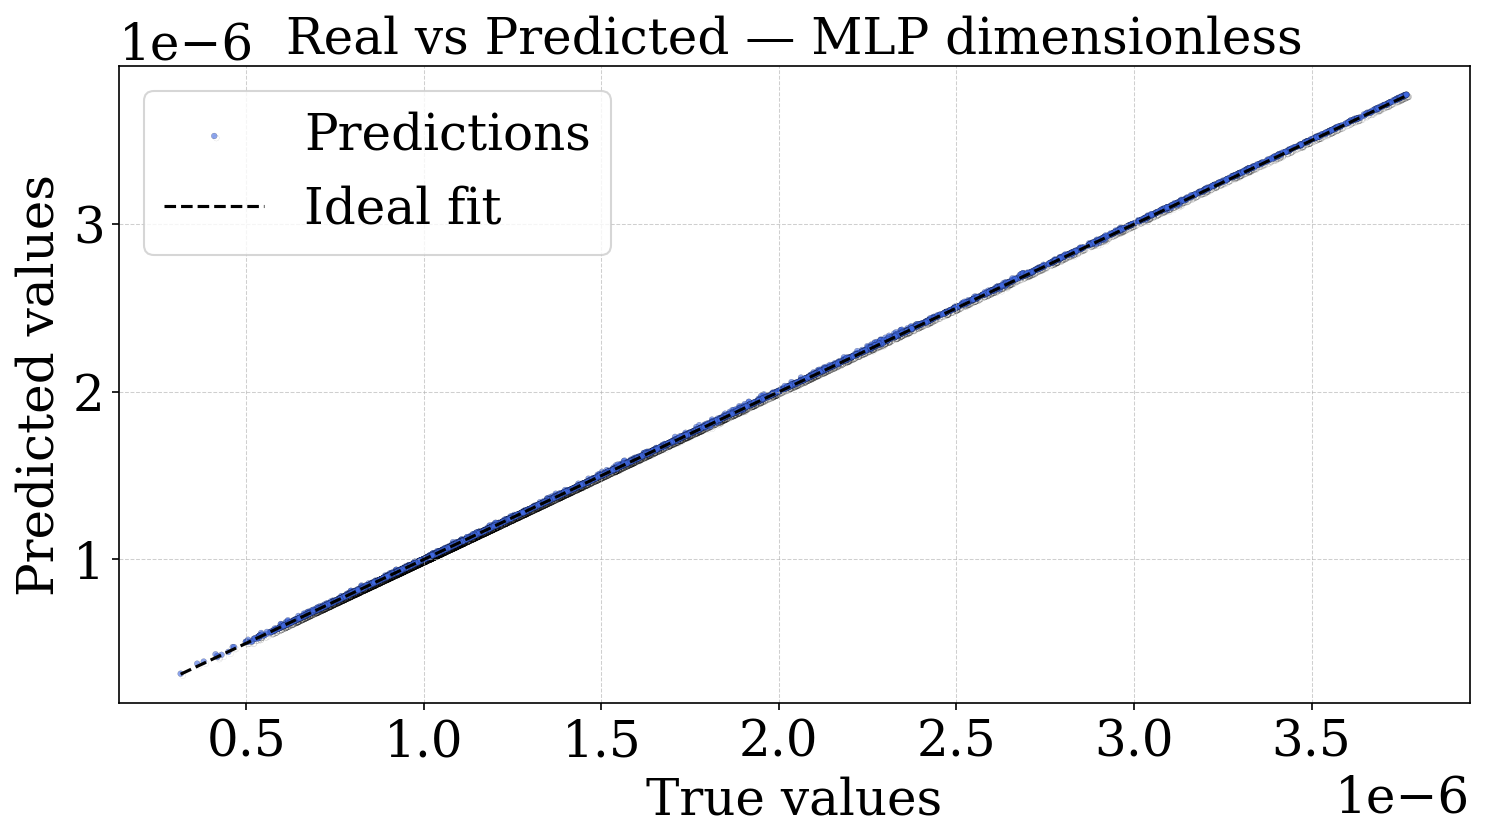

In [27]:
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(w, h_fig), dpi=150)
shadow = [pe.SimpleLineShadow(offset=(1,-1), alpha=0.25), pe.Normal()]
sc = ax.scatter(y_test_true, y_test_pred, s=8, alpha=0.6,
                color='royalblue', edgecolor='black', linewidth=0.1,
                label='Predictions')
sc.set_path_effects(shadow)
mn = float(min(y_test_true.min(), y_test_pred.min()))
mx = float(max(y_test_true.max(), y_test_pred.max()))
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Ideal fit')
ax.set_title("Real vs Predicted — MLP dimensionless")
ax.set_xlabel("True values")
ax.set_ylabel("Predicted values")
ax.legend()
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.savefig("real_vs_pred_mlp_dimless.pdf", dpi=400, bbox_inches='tight')
plt.show()


## Prediction heatmap in dimensionless space  (fixed d = 10 mm)

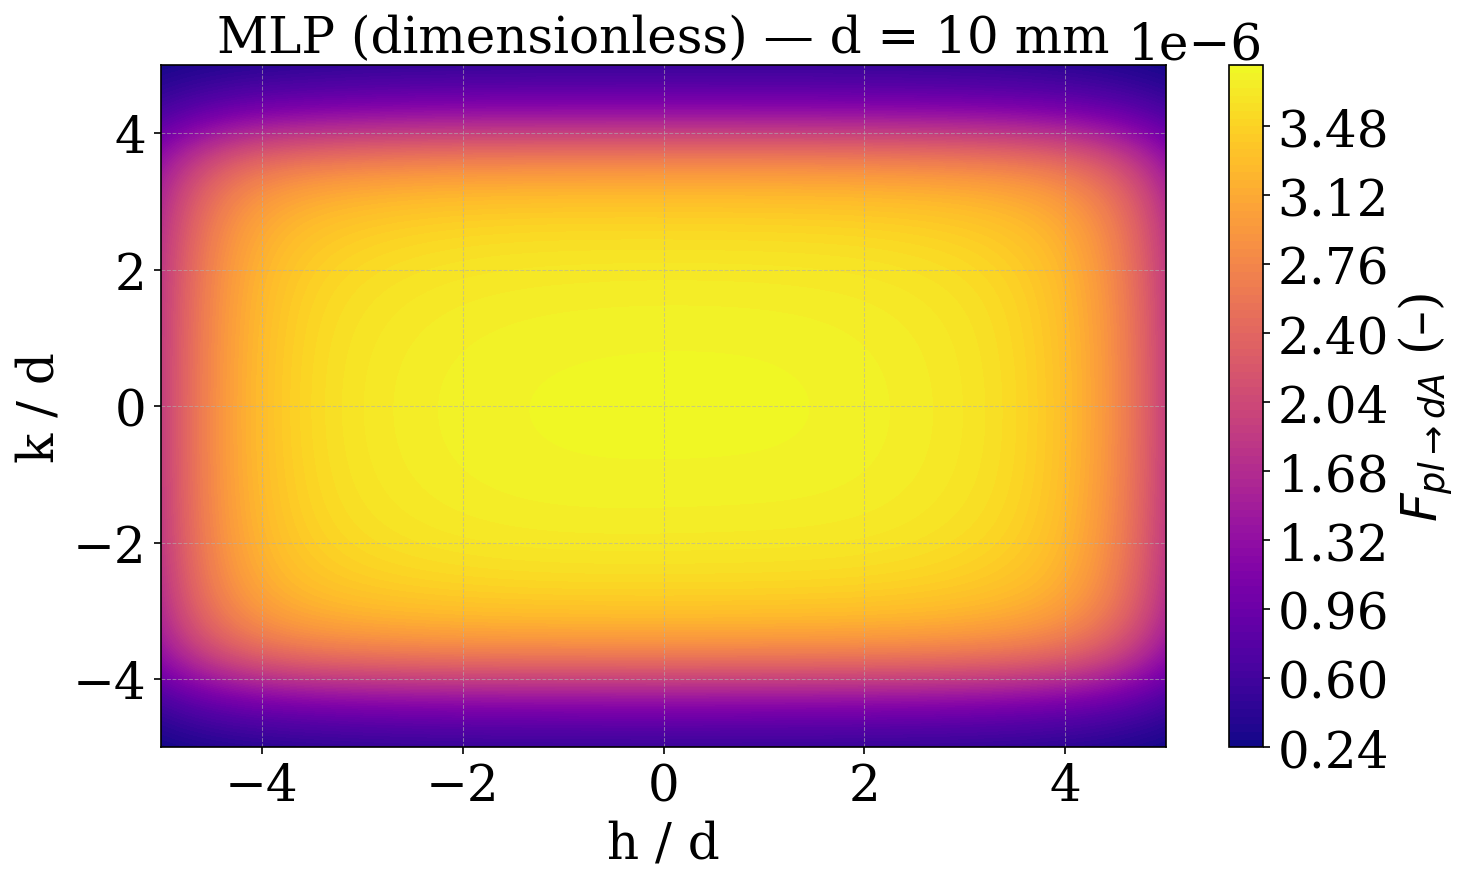

In [28]:
d_fixed = 10.0
hd_vals = np.linspace(-5, 5, 200)
kd_vals = np.linspace(-5, 5, 200)
Hd, Kd  = np.meshgrid(hd_vals, kd_vals)

Ld = np.full_like(Hd, L / d_fixed)
Pd = np.full_like(Hd, P / d_fixed)
Rd = np.full_like(Hd, R / d_fixed)

X_grid = np.stack([Hd.ravel(), Kd.ravel(), Ld.ravel(), Pd.ravel(), Rd.ravel()], axis=1)
X_grid_s = scaler_X.transform(X_grid)

model.eval()
with torch.no_grad():
    F_s = model(torch.tensor(X_grid_s, dtype=torch.float32).to(device)).cpu().numpy()

F_grid = scaler_y.inverse_transform(F_s).reshape(Hd.shape)

fig, ax = plt.subplots(figsize=(w, h_fig), dpi=150)
cf = ax.contourf(Hd, Kd, F_grid, levels=100, cmap='plasma')
cbar = fig.colorbar(cf)
cbar.set_label(r'$F_{pl\to dA}$ (–)')
ax.set_title(f"MLP (dimensionless) — d = {d_fixed:.0f} mm")
ax.set_xlabel("h / d")
ax.set_ylabel("k / d")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.savefig("heatmap_mlp_dimless.pdf", dpi=400, bbox_inches='tight')
plt.show()


# SHAP Analysis

## Setup and compute SHAP values

In [29]:
import shap

device_shap = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device_shap)
model.eval()

torch.manual_seed(42)
n_bg  = 200
idx_bg = torch.randperm(X_train_tensor.shape[0])[:n_bg]
background = X_train_tensor[idx_bg].to(device_shap)

explainer = shap.GradientExplainer(model, background)

n_explain = min(1000, X_test_tensor.shape[0])
X_explain = X_test_tensor[:n_explain].to(device_shap)
shap_values = explainer.shap_values(X_explain)

shap_vals = shap_values[0] if isinstance(shap_values, list) else shap_values
if shap_vals.ndim == 3:
    shap_vals = shap_vals.squeeze(-1)

feature_names_shap = ['h/d', 'k/d', 'L/d', 'P/d', 'R/d']
X_explain_orig = X_test[:n_explain]

print(f"SHAP values shape: {shap_vals.shape}")
print("Mean |SHAP| per feature:")
for i, name in enumerate(feature_names_shap):
    print(f"  {name}: {np.abs(shap_vals[:, i]).mean():.6f}")

print("\nNote: L/d, P/d, R/d are collinear — SHAP may distribute")
print("their combined contribution arbitrarily among the three.")


SHAP values shape: (1000, 5)
Mean |SHAP| per feature:
  h/d: 0.491603
  k/d: 0.698711
  L/d: 0.509817
  P/d: 0.665004
  R/d: 0.469778

Note: L/d, P/d, R/d are collinear — SHAP may distribute
their combined contribution arbitrarily among the three.


## Bar plot (global importance)

/tmp/ipykernel_3704103/3568291590.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_explain_orig, feature_names=feature_names_shap,


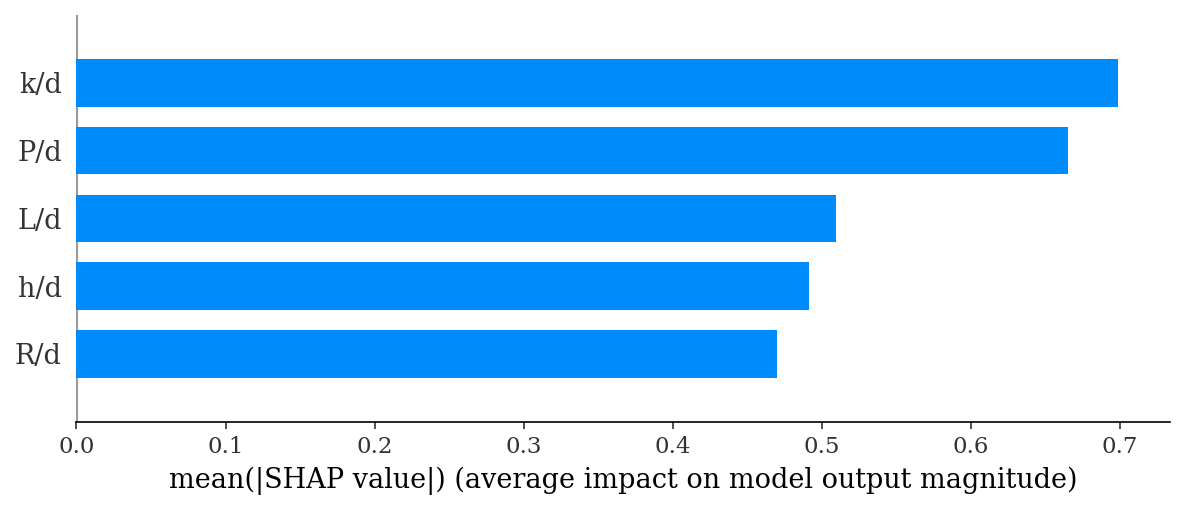

In [30]:
plt.figure(figsize=(8, 5), dpi=150)
shap.summary_plot(shap_vals, X_explain_orig, feature_names=feature_names_shap,
                  plot_type='bar', show=False)
plt.tight_layout()
plt.savefig("shap_bar_dimless.pdf", dpi=400, bbox_inches='tight')
plt.show()


## Beeswarm plot

/tmp/ipykernel_3704103/1554648892.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_explain_orig, feature_names=feature_names_shap, show=False)


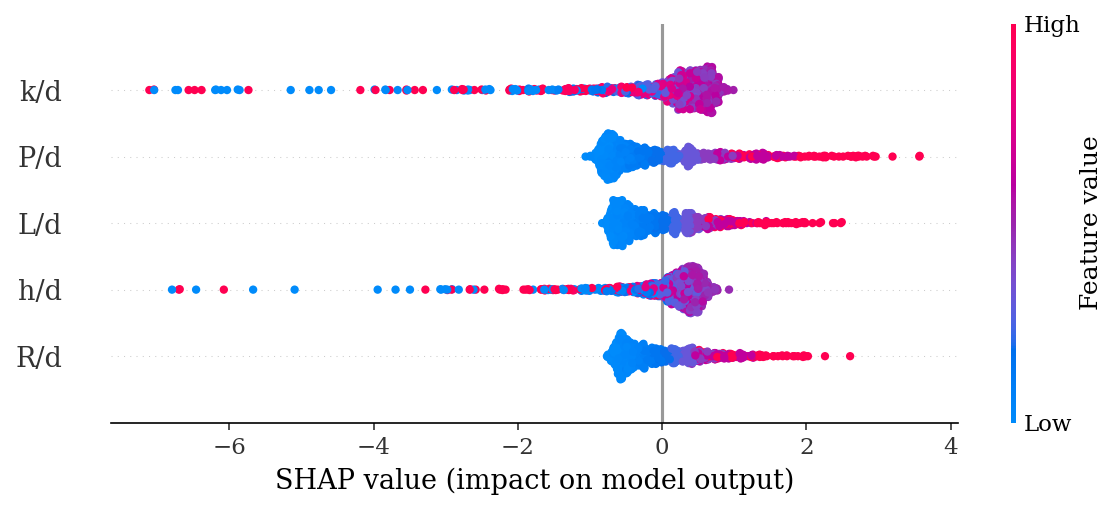

In [31]:
plt.figure(figsize=(8, 6), dpi=150)
shap.summary_plot(shap_vals, X_explain_orig, feature_names=feature_names_shap, show=False)
plt.tight_layout()
plt.savefig("shap_beeswarm_dimless.pdf", dpi=400, bbox_inches='tight')
plt.show()


## Dependence plots

<Figure size 1200x750 with 0 Axes>

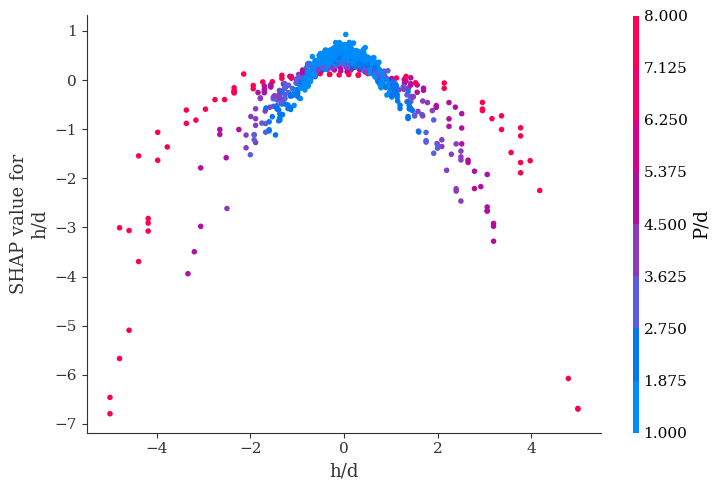

<Figure size 1200x750 with 0 Axes>

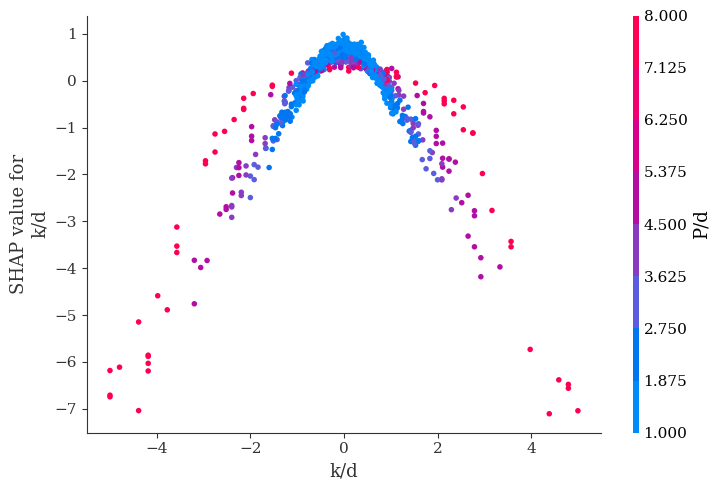

<Figure size 1200x750 with 0 Axes>

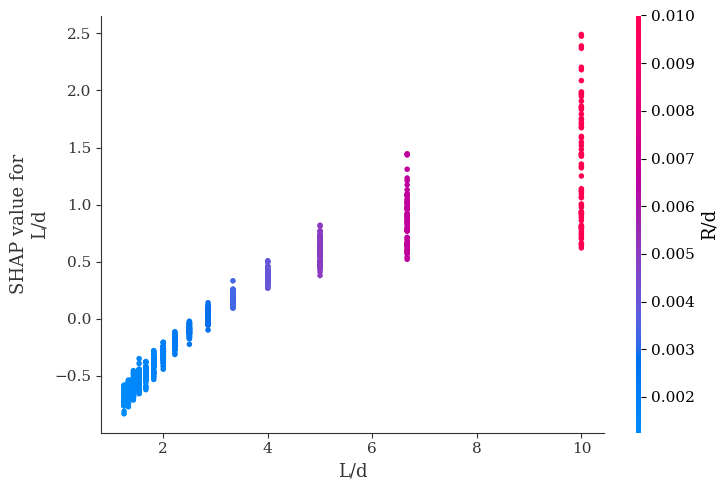

<Figure size 1200x750 with 0 Axes>

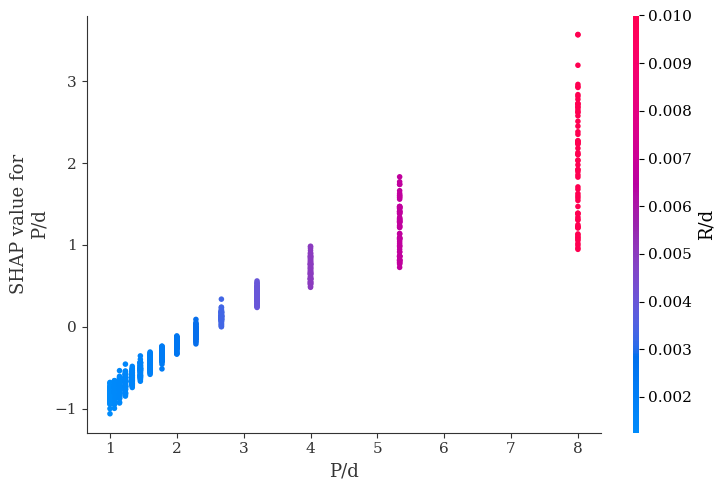

<Figure size 1200x750 with 0 Axes>

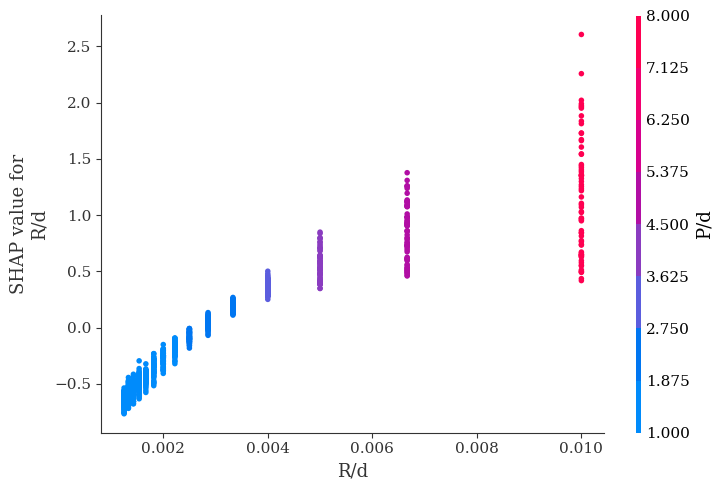

In [32]:
for i, name in enumerate(feature_names_shap):
    plt.figure(figsize=(8, 5), dpi=150)
    shap.dependence_plot(i, shap_vals, X_explain_orig,
                         feature_names=feature_names_shap, show=False)
    plt.tight_layout()
    fname = name.replace('/', '_')
    plt.savefig(f"shap_dependence_{fname}_dimless.pdf", dpi=400, bbox_inches='tight')
    plt.show()
